# VahaanBandhu 2.0 — Classical and Quantum-Enhanced Route Optimization

**Phase-A research notebook**

This notebook defines the VahaanBandhu routing problem, builds classical baselines,
derives a quantum formulation, validates it classically, runs it on a simulator, and
compares everything on **identical instances against identical cost matrices**.

## The research question, stated precisely

> Can quantum or hybrid quantum-classical optimization improve candidate-route selection
> or constrained circular-logistics optimization, *after* the classical road network has
> already reduced the search space?

Note what this question is not. It is not "is quantum faster". Every runtime comparison
below decomposes into classical preprocessing, solver time, quantum execution and
postprocessing, because a simulator beating an inefficient Python loop demonstrates
nothing about quantum computing.

## The architectural rule this notebook exists to justify

Quantum hardware is **never** called in the live request path. Queue latency alone makes
that indefensible for a farmer requesting a truck. Hardware is an offline research and
benchmarking instrument; its *outputs* — validated parameters, benchmark references,
route priors — are what production may consume.

In [1]:
import sys, json, time, warnings
from pathlib import Path
warnings.filterwarnings("ignore", category=DeprecationWarning)
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 220); pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True; plt.rcParams["grid.alpha"] = 0.3
print("ready")

ready


## Part 1 — Problem definition

VahaanBandhu's routing problem is broader than "shortest path from A to B". The node
types and their relationships:

| Node | Role |
|---|---|
| **farmer node** | crop pickup point (privacy-safe, never a residence) |
| **mandi** | agricultural market, the forward destination |
| **shop** | rural building-material dealer, the return destination |
| **depot** | truck home base; start and end of a circular tour |

The sequences that matter:

```
truck -> farm -> mandi                          (forward only)
truck -> farm(s) -> mandi                       (milk-run collection)
truck -> farm -> mandi -> supplier -> shop -> depot   (circular)
```

The last one is the product thesis. A truck that carries grain to a mandi and drives
home empty wastes half its distance. If a building-material load is waiting near that
mandi and heading back along the same corridor, the same kilometres earn twice.

**The objective is therefore multi-dimensional**, and the shortest route is frequently
not the best one:

```
minimize   distance + time + fuel + toll + risk + empty_km_penalty
                    - circular_logistics_benefit
```

In [2]:
from routing.objective import DEFAULT_WEIGHTS
from vb.generate.instances import DEFAULT_OBJECTIVE_WEIGHTS

print("Objective weights (stored in data and carried on every instance):")
print(json.dumps(DEFAULT_WEIGHTS, indent=2))
assert DEFAULT_WEIGHTS == DEFAULT_OBJECTIVE_WEIGHTS, "engine and dataset weights diverged"
print("\nEngine and dataset weight definitions agree.")
print("Note circular_bonus is NEGATIVE: a return load improves the objective.")

Objective weights (stored in data and carried on every instance):
{
  "distance_km": 1.0,
  "time_min": 0.35,
  "fuel_inr": 0.01,
  "toll_inr": 0.01,
  "risk": 12.0,
  "empty_km": 0.85,
  "circular_bonus": -1.1
}

Engine and dataset weight definitions agree.
Note circular_bonus is NEGATIVE: a return load improves the objective.


## Part 2 — Data loading

In [3]:
from vb import config as C

locations = pd.read_csv(C.MASTER/"locations_master.csv")
mandis    = pd.read_csv(C.MASTER/"mandis.csv")
shops     = pd.read_csv(C.SYNTHETIC/"shops.csv")
farmers   = pd.read_csv(C.SYNTHETIC/"farmer_nodes.csv")
trucks    = pd.read_csv(C.SYNTHETIC/"trucks.csv")
requests  = pd.read_csv(C.SYNTHETIC/"transport_requests.csv", low_memory=False)
edges     = pd.read_csv(C.SYNTHETIC/"route_edges.csv")
instances = pd.read_csv(C.SYNTHETIC/"route_instances.csv")

for name, df in [("locations",locations),("mandis",mandis),("shops",shops),
                 ("farmer_nodes",farmers),("trucks",trucks),("requests",requests),
                 ("route_edges",edges),("route_instances",instances)]:
    print(f"  {name:16s} {len(df):>8,} rows")
print(f"\nscenarios in graph: {sorted(edges.scenario_id.unique())}")

  locations           3,442 rows
  mandis                 50 rows
  shops                 900 rows
  farmer_nodes        1,400 rows
  trucks                600 rows
  requests           18,000 rows
  route_edges       375,968 rows
  route_instances     2,000 rows

scenarios in graph: ['SCN_BASELINE', 'SCN_EVENING_PEAK', 'SCN_HARVEST_PEAK', 'SCN_MIDDAY', 'SCN_MONSOON_RAIN', 'SCN_MORNING_PEAK', 'SCN_NIGHT', 'SCN_WEEKEND']


## Part 3 — Geospatial visualization

road graph: 3,442 nodes, 46,996 directed edges


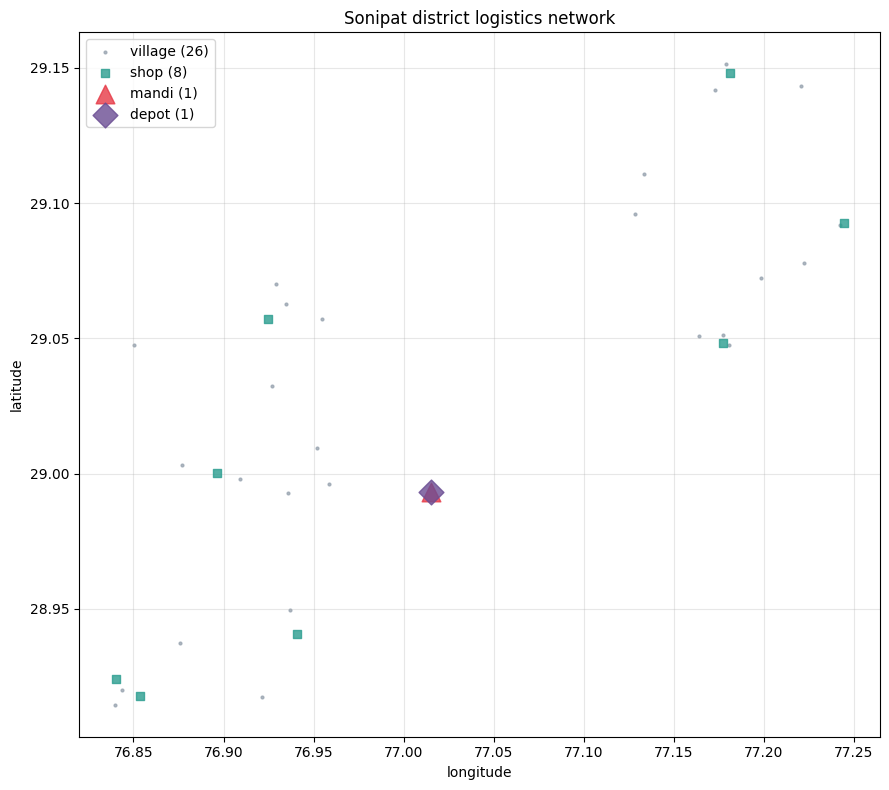

In [4]:
from routing.providers.offline import OfflineGraphProvider
provider = OfflineGraphProvider(edges, locations, scenario_id="SCN_BASELINE")
print(f"road graph: {provider.G.number_of_nodes():,} nodes, {provider.G.number_of_edges():,} directed edges")

# Focus on one district so the picture is readable.
DISTRICT = "Sonipat"
loc_d = locations[locations.district == DISTRICT]
fig, ax = plt.subplots(figsize=(9, 8))
style = {"village":("#9aa5b1",4,"o"), "shop":("#2a9d8f",26,"s"),
         "mandi":("#e63946",180,"^"), "depot":("#6a4c93",160,"D")}
for t,(c,s,m) in style.items():
    g = loc_d[loc_d.location_type == t]
    ax.scatter(g.longitude, g.latitude, c=c, s=s, marker=m, label=f"{t} ({len(g)})",
               alpha=0.8, zorder=3 if t!="village" else 1)
ax.set(title=f"{DISTRICT} district logistics network", xlabel="longitude", ylabel="latitude")
ax.legend(); plt.tight_layout(); plt.show()

Circular chain candidate:
  depot    LOC_2E9E391564C2  Sonipat Transport Depot                (28.9931,77.0151)
  farm     LOC_A02EDB30449A  Jhinjhana Nagar                        (29.0777,77.2222)
  mandi    LOC_2D9C52DA14E3  Sonipat Grain Market                   (28.9931,77.0151)
  shop     LOC_F9EDEB0869A0  Gupta Building Materials               (29.0572,76.9249)


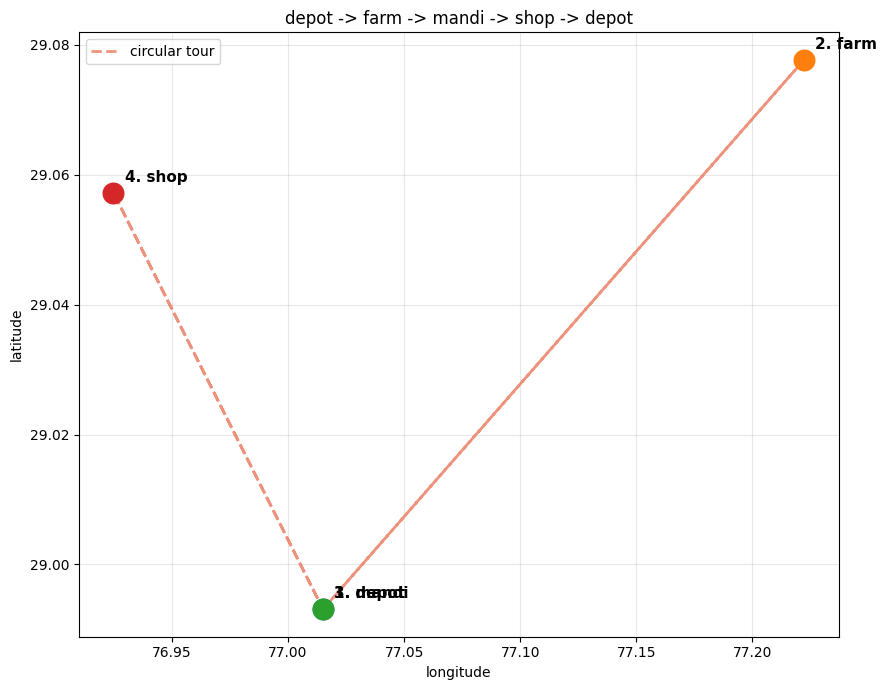

In [5]:
# A concrete truck -> farm -> mandi -> shop chain, drawn on the road graph.
from vb.geo import haversine_km
import networkx as nx

depot_row = locations[(locations.district==DISTRICT)&(locations.location_type=="depot")].iloc[0]
mandi_row = locations[(locations.district==DISTRICT)&(locations.location_type=="mandi")].iloc[0] \
            if ((locations.district==DISTRICT)&(locations.location_type=="mandi")).any() \
            else locations[locations.location_type=="mandi"].iloc[0]
village_row = locations[(locations.district==DISTRICT)&(locations.location_type=="village")].iloc[0]
shop_row = locations[(locations.district==DISTRICT)&(locations.location_type=="shop")].iloc[0]

chain = [("depot",depot_row),("farm",village_row),("mandi",mandi_row),("shop",shop_row)]
print("Circular chain candidate:")
for label,row in chain:
    print(f"  {label:8s} {row.location_id}  {row.name_en[:38]:38s} ({row.latitude:.4f},{row.longitude:.4f})")

fig, ax = plt.subplots(figsize=(9,7))
for i,(label,row) in enumerate(chain):
    ax.scatter(row.longitude,row.latitude,s=220,zorder=5)
    ax.annotate(f"{i+1}. {label}", (row.longitude,row.latitude),
                xytext=(8,8), textcoords="offset points", fontsize=11, weight="bold")
seq = chain + [chain[0]]
ax.plot([r.longitude for _,r in seq], [r.latitude for _,r in seq],
        "--", c="#e76f51", lw=2, alpha=0.75, label="circular tour")
ax.set(title="depot -> farm -> mandi -> shop -> depot", xlabel="longitude", ylabel="latitude")
ax.legend(); plt.tight_layout(); plt.show()

## Part 4 — Routing providers and candidate retrieval

The optimization layer never touches vendor JSON. It consumes `RouteCandidate` objects
from a `RoutingProvider`, which means TomTom can be swapped, mocked or unavailable
without any solver changing.

**On caching and licensing:** TomTom responses go into a short-TTL *operational* cache,
never into `Data/`. Their terms on storing and redistributing responses as derived
training data are unverified, which is why `route_edges` ships with offline
detour-model costs instead.

In [6]:
from routing.providers.tomtom import TomTomRoutingProvider
tomtom = TomTomRoutingProvider()
print(f"TomTom configured: {bool(tomtom._keys)} ({len(tomtom._keys)} keys)")
print(f"TomTom available : {tomtom.available}")
print("\nThis notebook runs entirely on the OFFLINE provider so it is reproducible")
print("without network access and consumes no API quota.")

TomTom configured: False (0 keys)
TomTom available : False

This notebook runs entirely on the OFFLINE provider so it is reproducible
without network access and consumes no API quota.


In [7]:
from routing.models import LatLon
from routing.classical.shortest_path import k_shortest_paths

origin_id, dest_id = village_row.location_id, mandi_row.location_id
cands = provider.get_alternative_routes(None, None, max_alternatives=4,
                                        origin_id=origin_id, destination_id=dest_id)
print(f"{len(cands)} candidate routes from {village_row.name_en} to {mandi_row.name_en}\n")
display(pd.DataFrame([c.to_dict() for c in cands])[
    ["route_id","distance_km","travel_time_min","traffic_delay_min",
     "toll_cost_inr","estimated_fuel_cost_inr","road_risk_score"]])

4 candidate routes from Jhinjhana Nagar to Sonipat Grain Market



,route_id,distance_km,travel_time_min,traffic_delay_min,toll_cost_inr,estimated_fuel_cost_inr,road_risk_score
0,OFF_LOC_A02E_LOC_2D9C_0,30.217,39.42,0.00,10.64,556.00,0.3645
1,OFF_LOC_A02E_LOC_2D9C_1,27.844,36.32,1.27,14.21,512.33,0.3910
2,OFF_LOC_A02E_LOC_2D9C_2,28.970,37.78,0.39,12.19,533.05,0.4415
3,OFF_LOC_A02E_LOC_2D9C_3,30.715,40.07,0.00,10.65,565.15,0.3847


## Part 5 — Candidate features and Experiment A/B

### EXPERIMENT A — simple A → B routing

In [8]:
from routing.classical.shortest_path import dijkstra, astar
coords = {r.location_id:(r.latitude,r.longitude) for r in locations.itertuples()}

dj = dijkstra(provider.G, origin_id, dest_id, weight="distance_km")
ast = astar(provider.G, origin_id, dest_id, coords, weight="distance_km")
print("EXPERIMENT A - shortest path A to B")
print(f"  Dijkstra: {dj.distance_km:8.2f} km  {len(dj.path)} hops  {dj.runtime_ms:.2f} ms")
print(f"  A*      : {ast.distance_km:8.2f} km  {len(ast.path)} hops  {ast.runtime_ms:.2f} ms")
assert abs(dj.cost-ast.cost)<1e-6, "A* heuristic is not admissible"
print("\n  Both find the same optimum -- the haversine heuristic is admissible,")
print("  because road distance is always at least the great-circle distance.")

EXPERIMENT A - shortest path A to B
  Dijkstra:    27.84 km  2 hops  1.19 ms
  A*      :    27.84 km  2 hops  0.25 ms

  Both find the same optimum -- the haversine heuristic is admissible,
  because road distance is always at least the great-circle distance.


### EXPERIMENT B — traffic-aware candidate selection

In [9]:
from routing.objective import select_best, explain_selection, score_candidate

best, breakdown, ranking = select_best(cands)
print("EXPERIMENT B - multi-objective selection among candidates\n")
rows=[]
for c,s in ranking:
    rows.append({"route_id":c.route_id,"dist_km":round(c.distance_km,1),
                 "eta_min":round(c.travel_time_min+c.traffic_delay_min,1),
                 "traffic_delay":round(c.traffic_delay_min,1),
                 "risk":round(c.road_risk_score,3),
                 "score":round(s.total,2)})
display(pd.DataFrame(rows))

shortest = min(cands, key=lambda c:c.distance_km)
print(f"\nshortest route : {shortest.route_id} ({shortest.distance_km:.1f} km)")
print(f"selected route : {best.route_id} ({best.distance_km:.1f} km)")
print("SAME" if shortest.route_id==best.route_id else "DIFFERENT -- distance alone was not decisive")
print("\nExplanation returned to the UI:")
print(json.dumps(explain_selection(best,breakdown,ranking), indent=2))

EXPERIMENT B - multi-objective selection among candidates



,route_id,dist_km,eta_min,traffic_delay,risk,score
0,OFF_LOC_A02E_LOC_2D9C_1,27.8,37.6,1.3,0.391,50.96
1,OFF_LOC_A02E_LOC_2D9C_2,29.0,38.2,0.4,0.442,53.08
2,OFF_LOC_A02E_LOC_2D9C_0,30.2,39.4,0.0,0.364,54.05
3,OFF_LOC_A02E_LOC_2D9C_3,30.7,40.1,0.0,0.385,55.11



shortest route : OFF_LOC_A02E_LOC_2D9C_1 (27.8 km)
selected route : OFF_LOC_A02E_LOC_2D9C_1 (27.8 km)
SAME

Explanation returned to the UI:
{
  "selected_route_id": "OFF_LOC_A02E_LOC_2D9C_1",
  "distance_km": 27.84,
  "eta_min": 37.6,
  "traffic_delay_min": 1.3,
  "estimated_fuel_cost_inr": 512.33,
  "estimated_toll_inr": 14.21,
  "total_estimated_cost_inr": 526.54,
  "empty_km": 0.0,
  "loaded_km": 27.84,
  "circular_logistics_score": 0.0,
  "selection_score": 50.958,
  "margin_over_runner_up": 2.122,
  "margin_is_decisive": true,
  "primary_selection_reasons": [
    "distance_km penalised (+27.8)",
    "time_min penalised (+13.2)",
    "fuel_inr penalised (+5.1)"
  ],
  "n_candidates_considered": 4
}


Note the `margin_is_decisive` field. When the top two routes score within 2% of each
other the engine reports a near-tie rather than presenting a confident winner — showing
false certainty to a driver is worse than showing none.

## Part 6 — Experiment C: truck → farm → mandi

In [10]:
from routing.engine import RouteEngine
from routing.circular import evaluate_direct_trip, evaluate_circular_trip, find_return_loads

engine = RouteEngine(primary_provider=provider, fallback_provider=None)
truck = trucks[trucks.district==DISTRICT].sort_values("capacity_kg",ascending=False).iloc[0]
print(f"Truck {truck.truck_id}: {truck.vehicle_class}, {truck.capacity_kg:,.0f} kg, {truck.avg_kmpl} kmpl")

LOAD_KG = 2000.0
decision = engine.select_route(None, None, origin_id=origin_id, destination_id=dest_id,
                               load_kg=LOAD_KG, vehicle_capacity_kg=truck.capacity_kg)
print(f"\nEXPERIMENT C - farm to mandi, {LOAD_KG:,.0f} kg")
print(f"  provider used : {decision.provider_used}")
print(f"  selected      : {decision.explanation['selected_route_id']}")
print(f"  distance      : {decision.explanation['distance_km']} km")
print(f"  ETA           : {decision.explanation['eta_min']} min")
print(f"  est. cost     : Rs {decision.explanation['total_estimated_cost_inr']}")
print(f"  candidates    : {decision.reduction_stats}")
print(f"  engine runtime: {decision.runtime_ms:.1f} ms")
for w in decision.warnings: print(f"  WARNING: {w}")

Truck TRK_72CA4D066FFF: 2axle, 10,560 kg, 5.99 kmpl

EXPERIMENT C - farm to mandi, 2,000 kg
  provider used : offline_graph
  selected      : OFF_LOC_A02E_LOC_2D9C_1
  distance      : 27.84 km
  ETA           : 37.6 min
  est. cost     : Rs 526.54
  candidates    : {'n_input': 4, 'n_after_pareto': 3, 'n_output': 3, 'n_dominated_removed': 1, 'truncated_by_budget': False, 'truncation_may_discard_optimum': False}
  engine runtime: 5.9 ms


## Part 7 — Experiment D: circular logistics

The comparison that defines the product: the same forward trip, with and without a
return load. A return load only counts if the detour is small relative to the empty
distance it replaces — a shop 80 km off the homeward path is a second job, not a
return load, and the scorer refuses to pretend otherwise.

In [11]:
village_ll = (village_row.latitude, village_row.longitude)
mandi_ll   = (mandi_row.latitude, mandi_row.longitude)
depot_ll   = (depot_row.latitude, depot_row.longitude)
shop_ll    = (shop_row.latitude, shop_row.longitude)
supplier_ll= (mandi_row.latitude+0.02, mandi_row.longitude+0.02)

direct = evaluate_direct_trip(village_ll, mandi_ll, depot_ll,
                              truck.avg_kmpl, truck.capacity_kg, LOAD_KG)
circular = evaluate_circular_trip(village_ll, mandi_ll, supplier_ll, shop_ll, depot_ll,
                                  truck.avg_kmpl, truck.capacity_kg, LOAD_KG, 3000.0)

comp = pd.DataFrame({"without return load":direct.to_dict(),
                     "with return load":circular.to_dict()})
display(comp.loc[["forward_loaded_km","return_loaded_km","empty_km","total_km",
                  "detour_km","truck_utilization","fuel_litres","fuel_cost_inr",
                  "co2_proxy_kg","avoided_empty_km","circular_score","worthwhile"]])
print(f"\nreason: {circular.reason}")
print(f"\nEmpty running: {direct.empty_km:.1f} km -> {circular.empty_km:.1f} km")
print(f"Truck utilization: {direct.truck_utilization:.1%} -> {circular.truck_utilization:.1%}")

,without return load,with return load
forward_loaded_km,30.01,30.01
return_loaded_km,0.0,15.91
empty_km,0.0,19.25
total_km,30.01,65.17
detour_km,0.0,35.17
truck_utilization,1.0,0.7046
fuel_litres,5.01,10.88
fuel_cost_inr,460.87,1000.98
co2_proxy_kg,13.43,29.16
avoided_empty_km,0.0,0.0



reason: detour 35.2 km is inf% of the 0.0 km empty leg it replaces -- above the 45% threshold

Empty running: 0.0 km -> 19.2 km
Truck utilization: 100.0% -> 70.5%


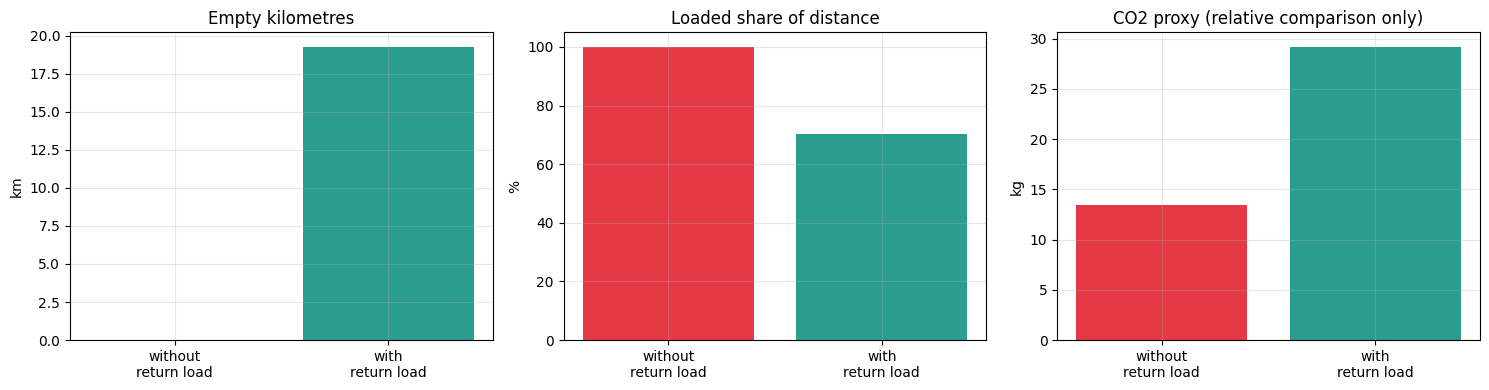

The CO2 figure is a fuel-derived proxy for comparing routes, not a certified estimate.


In [12]:
fig, axes = plt.subplots(1,3, figsize=(15,4))
labels=["without\nreturn load","with\nreturn load"]
axes[0].bar(labels,[direct.empty_km,circular.empty_km],color=["#e63946","#2a9d8f"])
axes[0].set(title="Empty kilometres",ylabel="km")
axes[1].bar(labels,[direct.truck_utilization*100,circular.truck_utilization*100],
            color=["#e63946","#2a9d8f"])
axes[1].set(title="Loaded share of distance",ylabel="%")
axes[2].bar(labels,[direct.co2_proxy_kg,circular.co2_proxy_kg],color=["#e63946","#2a9d8f"])
axes[2].set(title="CO2 proxy (relative comparison only)",ylabel="kg")
plt.tight_layout(); plt.show()
print("The CO2 figure is a fuel-derived proxy for comparing routes, not a certified estimate.")

## Part 8 — Experiment E: operations research baselines

Strong classical baselines come *before* any quantum claim. Where the instance is small
enough, an exact solver provides ground truth, so later results can be reported as a
genuine optimality gap rather than "close to a heuristic".

In [13]:
from routing.instances import list_instances, load_instance
from routing.classical.vrp import solve_vrp

vrp_inst = list_instances(problem_type="CVRP", limit=1)
if len(vrp_inst)==0:
    vrp_inst = list_instances(limit=1)
iid = vrp_inst.iloc[0].instance_id
inst = load_instance(iid)
print(f"instance {iid}")
print(f"  problem     : {inst.problem_type}")
print(f"  nodes       : {inst.n_nodes} ({inst.n_customers} customers + depot)")
print(f"  vehicles    : {len(inst.vehicle_capacities)}")
print(f"  demand      : {inst.demands.sum():,.0f} kg")
print(f"  capacity    : {sum(inst.vehicle_capacities):,.0f} kg")
print(f"  cost snapshot: {inst.cost_snapshot_id}")

sol = solve_vrp(inst, time_limit_s=8, seed=42)
print(f"\nOR-Tools: feasible={sol.feasible}  distance={sol.total_distance_km:.2f} km")
print(f"  routes={len(sol.ordered_stops)}  empty={sol.empty_distance_km:.2f} km")
print(f"  objective={sol.objective_value:.2f}  solver={sol.solver_runtime_ms:.0f} ms")
print(f"  cost_snapshot_id={sol.cost_snapshot_id}")

instance INS_0F9F0C4ACF56
  problem     : CVRP
  nodes       : 5 (4 customers + depot)
  vehicles    : 1
  demand      : 3,630 kg
  capacity    : 17,490 kg
  cost snapshot: CST_48011250D4FB



OR-Tools: feasible=True  distance=96.14 km
  routes=1  empty=14.24 km
  objective=169.91  solver=8002 ms
  cost_snapshot_id=CST_48011250D4FB


In [14]:
from routing.classical.heuristics import (brute_force_tsp, nearest_neighbour,
                                          two_opt, simulated_annealing)
small = list_instances(quantum_ready=True, limit=1).iloc[0].instance_id
si = load_instance(small)
D = si.distance_matrix
print(f"EXPERIMENT E - classical solvers on {small} ({si.n_nodes} nodes)\n")
exact = brute_force_tsp(D)
nn = nearest_neighbour(D); opt = two_opt(D, nn.tour); sa = simulated_annealing(D, seed=1)
res = pd.DataFrame([
    {"algorithm":r.algorithm,"cost_km":round(r.cost,3),"runtime_ms":round(r.runtime_ms,3),
     "gap_vs_optimum":round((r.cost-exact.cost)/exact.cost,5)}
    for r in [exact,nn,opt,sa]])
display(res)
print("\nThe exact row is ground truth. Every gap below is measured against it,")
print("not against another heuristic.")

EXPERIMENT E - classical solvers on INS_A9CA499BC8FF (4 nodes)



,algorithm,cost_km,runtime_ms,gap_vs_optimum
0,brute_force_exact,154.831,0.053,0.00000
1,nearest_neighbour,156.044,0.027,0.00783
2,two_opt,154.831,0.053,0.00000
3,simulated_annealing,154.831,671.745,0.00000



The exact row is ground truth. Every gap below is measured against it,
not against another heuristic.


## Part 9 — Quantum problem formulation

### Deriving the formulation before writing any Qiskit

**Permutation TSP encoding.** Binary variable $x_{i,t}=1$ iff node $i$ is visited at
position $t$:

$$
\min \sum_{t}\sum_{i \ne j} D_{ij}\, x_{i,t}\, x_{j,t+1}
\;+\; A\sum_i\Big(\sum_t x_{i,t}-1\Big)^2
\;+\; A\sum_t\Big(\sum_i x_{i,t}-1\Big)^2
$$

This needs $n^2$ binary variables. **That is the problem**: 4 nodes is 16 qubits,
5 is 25, 7 is 49. A statevector simulator holds $2^{22}$ amplitudes comfortably and
$2^{49}$ never. This is a measured limit, not a tuning issue.

**Edge-selection encoding** (following Innan et al., *QUAV*, arXiv 2508.21361, which
assigns one qubit per path segment). One binary variable per candidate edge:

$$
\min \sum_{e} c_e\, y_e \;+\; A\sum_{v\in V}\Big(\sum_{e\in \delta^+(v)} y_e - \sum_{e\in \delta^-(v)} y_e - b_v\Big)^2
$$

with $b_v = +1$ at the source, $-1$ at the sink, $0$ elsewhere. This scales with
**edges**, not nodes squared — a 20-edge corridor problem is 20 qubits regardless of
how large the underlying road network is.

### A necessary critique of the source paper

QUAV's cost Hamiltonian is $H_C=\sum_i C(e_i) Z_i$ — **purely linear**. A linear
Hamiltonian is separable: each qubit's optimal value can be read off independently, no
entanglement is required, and QAOA offers nothing over inspection.

Our formulation therefore adds the squared flow-conservation terms, which produce
genuine $Z_iZ_j$ couplings. Those couplings are what make running QAOA a meaningful
thing to do here rather than a decorative one. We verify below that the circuit
actually contains entangling gates.

### Penalty weights

Penalties are derived, not guessed: set strictly above the largest achievable cost
saving, so violating a constraint can never pay for itself. We test this property
exhaustively rather than asserting it.

## Part 10 — QUBO construction

In [15]:
from routing.quantum.qubo import (build_tsp_qubo, build_edge_selection_qubo,
                                  brute_force_qubo, QUBO_VERSION)
from routing.quantum.decoder import decode

# A small, hand-checkable diamond graph: 0->{1,2}->3 plus an expensive direct link.
demo_edges = [(0,1),(1,3),(0,2),(2,3),(0,3)]
demo_costs = np.array([2.0,2.0,1.0,1.5,9.0])
q_edge = build_edge_selection_qubo(demo_edges, demo_costs, source=0, sink=3, n_nodes=4)
print("Edge-selection QUBO:"); print(json.dumps(q_edge.summary(), indent=2))
print(f"\nQ matrix ({q_edge.n_vars}x{q_edge.n_vars}):"); print(np.round(q_edge.Q,2))

Edge-selection QUBO:
{
  "qubo_version": "qubo_v1",
  "encoding": "edge_selection_v1",
  "n_vars": 5,
  "n_quadratic_terms": 8,
  "penalty": 25.5,
  "max_abs_coefficient": 51.0,
  "constant_offset": 51.0,
  "n_edges": 5,
  "n_nodes": 4,
  "source": 0,
  "sink": 3,
  "problem": "constrained_path_selection"
}

Q matrix (5x5):
[[  2.  -51.   51.    0.   51. ]
 [  0.    2.    0.   51.   51. ]
 [  0.    0.    1.  -51.   51. ]
 [  0.    0.    0.    1.5  51. ]
 [  0.    0.    0.    0.  -42. ]]


In [16]:
q_tsp = build_tsp_qubo(D[:4,:4])
print("Encoding cost comparison on the same 4-node problem:")
print(f"  permutation encoding : {q_tsp.n_vars} qubits")
print(f"  edge-selection (5 edges): {q_edge.n_vars} qubits")
print("\nScaling of the permutation encoding:")
for n in range(3,9):
    print(f"  {n} nodes -> {n*n:3d} qubits -> statevector needs 2^{n*n} = {2**(n*n):.3g} amplitudes")
print("\nThis is why QUANTUM_NODE_CEILING is 3 customers, and why the edge")
print("encoding is the one the hybrid pipeline actually uses.")

Encoding cost comparison on the same 4-node problem:
  permutation encoding : 16 qubits
  edge-selection (5 edges): 5 qubits

Scaling of the permutation encoding:
  3 nodes ->   9 qubits -> statevector needs 2^9 = 512 amplitudes
  4 nodes ->  16 qubits -> statevector needs 2^16 = 6.55e+04 amplitudes
  5 nodes ->  25 qubits -> statevector needs 2^25 = 3.36e+07 amplitudes
  6 nodes ->  36 qubits -> statevector needs 2^36 = 6.87e+10 amplitudes
  7 nodes ->  49 qubits -> statevector needs 2^49 = 5.63e+14 amplitudes
  8 nodes ->  64 qubits -> statevector needs 2^64 = 1.84e+19 amplitudes

This is why QUANTUM_NODE_CEILING is 3 customers, and why the edge
encoding is the one the hybrid pipeline actually uses.


## Part 11 — Experiment F: classical QUBO validation (mandatory)

**This step is not optional.** A QUBO that does not encode the routing problem can
still produce a beautifully converging QAOA run — of the wrong problem. Before any
quantum execution we prove three properties by exhaustive enumeration.

In [17]:
import itertools
print("EXPERIMENT F - QUBO validation\n")

x_opt, e_opt = brute_force_qubo(q_edge)
dec = decode(x_opt, q_edge)
print(f"1. Optimum decodes to a valid route")
print(f"   selection : {x_opt.astype(int)}")
print(f"   path      : {dec.tour}   feasible={dec.feasible}")
print(f"   energy    : {e_opt:.3f}")
print(f"   true cheapest path is 0->2->3 costing 1.0 + 1.5 = 2.5")
assert dec.feasible and dec.tour==[0,2,3] and abs(e_opt-2.5)<1e-9

feas, infeas = [], []
for bits in itertools.product([0,1], repeat=q_edge.n_vars):
    x=np.array(bits,dtype=float)
    (feas if decode(x,q_edge).feasible else infeas).append(q_edge.energy(x))
print(f"\n2. Penalty separation (the penalty-method requirement)")
print(f"   worst feasible energy  : {max(feas):.3f}")
print(f"   best infeasible energy : {min(infeas):.3f}")
assert max(feas) < min(infeas)
print("   PASS - no constraint violation can ever be cheaper than obeying it")

off = q_edge.Q[np.triu_indices_from(q_edge.Q,k=1)]
print(f"\n3. Genuine quadratic structure")
print(f"   non-zero ZZ coupling terms: {np.count_nonzero(off)}")
assert np.count_nonzero(off) > 0
print("   PASS - this is not a separable (classically trivial) Hamiltonian")

EXPERIMENT F - QUBO validation

1. Optimum decodes to a valid route
   selection : [0 0 1 1 0]
   path      : [0, 2, 3]   feasible=True
   energy    : 2.500
   true cheapest path is 0->2->3 costing 1.0 + 1.5 = 2.5

2. Penalty separation (the penalty-method requirement)
   worst feasible energy  : 9.000
   best infeasible energy : 51.000
   PASS - no constraint violation can ever be cheaper than obeying it

3. Genuine quadratic structure
   non-zero ZZ coupling terms: 8
   PASS - this is not a separable (classically trivial) Hamiltonian


In [18]:
# Ising conversion must preserve every energy exactly.
h, J, offset = q_edge.to_ising()
maxerr = 0.0
for bits in itertools.product([0,1], repeat=q_edge.n_vars):
    x=np.array(bits,dtype=float); z=1-2*x
    maxerr=max(maxerr, abs(float(h@z + z@J@z + offset) - q_edge.energy(x)))
print(f"QUBO -> Ising max energy error over all {2**q_edge.n_vars} states: {maxerr:.2e}")
assert maxerr < 1e-9
print("Ising conversion is exact.")

QUBO -> Ising max energy error over all 32 states: 0.00e+00
Ising conversion is exact.


## Part 12 — Experiment G: QAOA on a simulator

In [19]:
from routing.quantum.qaoa import run_qaoa, build_qaoa_circuit

qc,_ = build_qaoa_circuit(q_edge, p=1)
print("Circuit gate counts (p=1):", dict(qc.count_ops()))
assert qc.count_ops().get("cx",0) > 0
print("CNOTs present -- the cost Hamiltonian genuinely entangles.\n")

print("EXPERIMENT G - QAOA on the edge-selection QUBO")
qa = run_qaoa(q_edge, p=3, shots=2048, seed=7, maxiter=60, D=None)
print(f"  qubits          : {qa.n_qubits}")
print(f"  circuit depth   : {qa.circuit_depth}")
print(f"  layers p        : {qa.n_layers}")
print(f"  shots           : {qa.shots}")
print(f"  optimizer       : {qa.optimizer} ({qa.n_iterations} iterations)")
print(f"  backend         : {qa.backend}")
print(f"  best energy     : {qa.best_energy:.4f}")
print(f"  classical optimum: {e_opt:.4f}")
print(f"  gap             : {qa.best_energy-e_opt:.6f}")
print(f"  FEASIBLE RATE   : {qa.feasible_rate:.2%}  <-- most shots violate constraints")
print(f"  wall clock      : {qa.runtime_ms:.0f} ms")

Circuit gate counts (p=1): {'cx': 16, 'rz': 13, 'h': 5, 'rx': 5, 'measure': 5, 'barrier': 2}
CNOTs present -- the cost Hamiltonian genuinely entangles.

EXPERIMENT G - QAOA on the edge-selection QUBO


  qubits          : 5
  circuit depth   : 62
  layers p        : 3
  shots           : 2048
  optimizer       : COBYLA (53 iterations)
  backend         : aer_simulator
  best energy     : 2.5000
  classical optimum: 2.5000
  gap             : 0.000000
  FEASIBLE RATE   : 10.45%  <-- most shots violate constraints
  wall clock      : 1379 ms


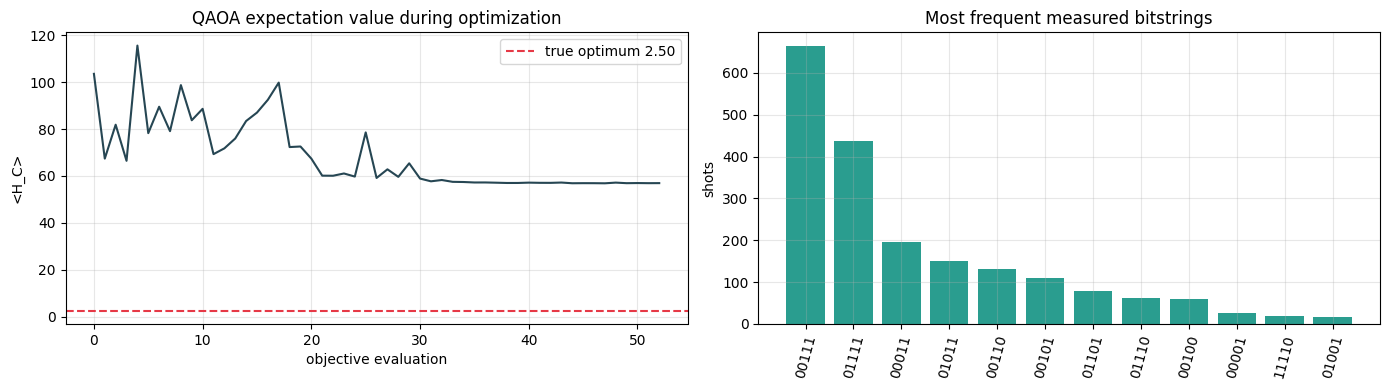

The expectation value stays well above the optimum because it averages over the
whole distribution, most of which is infeasible. Reporting only the best sample
without the feasible rate would badly overstate the method.


In [20]:
fig, axes = plt.subplots(1,2, figsize=(14,4))
axes[0].plot(qa.cost_history, lw=1.5, color="#264653")
axes[0].axhline(e_opt, ls="--", c="#e63946", label=f"true optimum {e_opt:.2f}")
axes[0].set(title="QAOA expectation value during optimization",
            xlabel="objective evaluation", ylabel="<H_C>")
axes[0].legend()

top = sorted(qa.counts.items(), key=lambda kv:-kv[1])[:12]
axes[1].bar([b for b,_ in top],[c for _,c in top], color="#2a9d8f")
axes[1].set(title="Most frequent measured bitstrings", ylabel="shots")
axes[1].tick_params(axis="x", rotation=75)
plt.tight_layout(); plt.show()
print("The expectation value stays well above the optimum because it averages over the")
print("whole distribution, most of which is infeasible. Reporting only the best sample")
print("without the feasible rate would badly overstate the method.")

## Part 13 — Experiment H: IBM Quantum hardware

Hardware execution is attempted only if credentials are configured and a backend is
reachable. If it is not, this experiment is recorded as **BLOCKED** — a simulator result
labelled as hardware would be a fabricated experimental claim.

In [21]:
from routing.quantum.ibm_runtime import IBMQuantumRunner
import os
runner = IBMQuantumRunner()
print("EXPERIMENT H - IBM Quantum hardware")
print(f"  token configured: {runner.status['token_configured']}")
status = runner.status
print(f"  connected       : {status['connected']}")
if status["error"]:
    print(f"  error           : {status['error']}")

if runner.available:
    backends = runner.list_backends(min_qubits=q_edge.n_vars)
    print(f"  backends available: {[b.name for b in backends][:5]}")
    hw = runner.run_circuit(qc, shots=1024)
    if hw["executed"]:
        from routing.quantum.decoder import decode_counts
        dc = decode_counts(hw["counts"], q_edge)
        print(f"  backend        : {hw['backend']}")
        print(f"  job id         : {hw['job_id']}")
        print(f"  transpiled depth: {hw['transpiled_depth']}")
        print(f"  feasible rate  : {dc['feasible_rate']:.2%}")
        HARDWARE_RESULT = hw
    else:
        print(f"  NOT EXECUTED: {hw['reason']}")
        HARDWARE_RESULT = None
else:
    HARDWARE_RESULT = None
    print("\n  STATUS: BLOCKED - hardware execution not performed.")
    print("  No simulator result is substituted or relabelled.")
    print("  To run: set IBM_QUANTUM_TOKEN in .env and re-execute this cell.")

EXPERIMENT H - IBM Quantum hardware
  token configured: False
  connected       : False

  STATUS: BLOCKED - hardware execution not performed.
  No simulator result is substituted or relabelled.
  To run: set IBM_QUANTUM_TOKEN in .env and re-execute this cell.


## Part 14 — Experiment I: full benchmark comparison

Every row below is computed on the **same instance against the same
`cost_snapshot_id`**. The benchmark harness refuses to compare across differing cost
snapshots, because such a comparison is meaningless no matter how it is presented.

Runtime is decomposed rather than totalled, and optimality gaps appear only where an
exact solver actually ran.

In [22]:
from routing.evaluation.benchmark import benchmark_instance, to_frame, summarise

qr = list_instances(quantum_ready=True, limit=8)
print(f"benchmarking {len(qr)} quantum-ready instances...")
rows=[]
for iid in qr.instance_id:
    bi = load_instance(iid)
    rows += benchmark_instance(bi, seed=11, qaoa_layers=2, qaoa_shots=1024)
bench = to_frame(rows)
print(f"{len(bench)} benchmark rows")
print(f"distinct cost snapshots: {bench.cost_snapshot_id.nunique()} (must be 1 for validity)")
display(summarise(bench))

benchmarking 8 quantum-ready instances...


48 benchmark rows
distinct cost snapshots: 1 (must be 1 for validity)


,algorithm_name,n_instances,mean_objective,mean_tour_km,feasible_rate,mean_gap,mean_solver_ms,mean_quantum_ms,mean_wall_ms,mean_sampling_feasible_rate
0,brute_force_exact,8,240.72175,240.721750,1.000,0.000000,0.037100,0.0000,0.037100,NaN
2,nearest_neighbour+2opt,8,240.72175,240.721750,1.000,0.000000,0.021087,0.0000,0.037012,NaN
5,simulated_annealing,8,240.72175,240.721750,1.000,0.000000,559.787837,0.0000,559.787837,NaN
4,qubo_brute_force,8,240.72175,240.721750,1.000,0.000000,454.304900,0.0000,454.508987,NaN
1,nearest_neighbour,8,242.63000,242.630000,1.000,0.015641,0.015925,0.0000,0.015925,NaN
3,qaoa_p2_simulator,8,inf,367.957333,0.375,0.160128,0.000000,4492.3947,4492.597825,0.00061


saved to Res/benchmarks/experiment_i_benchmark.csv



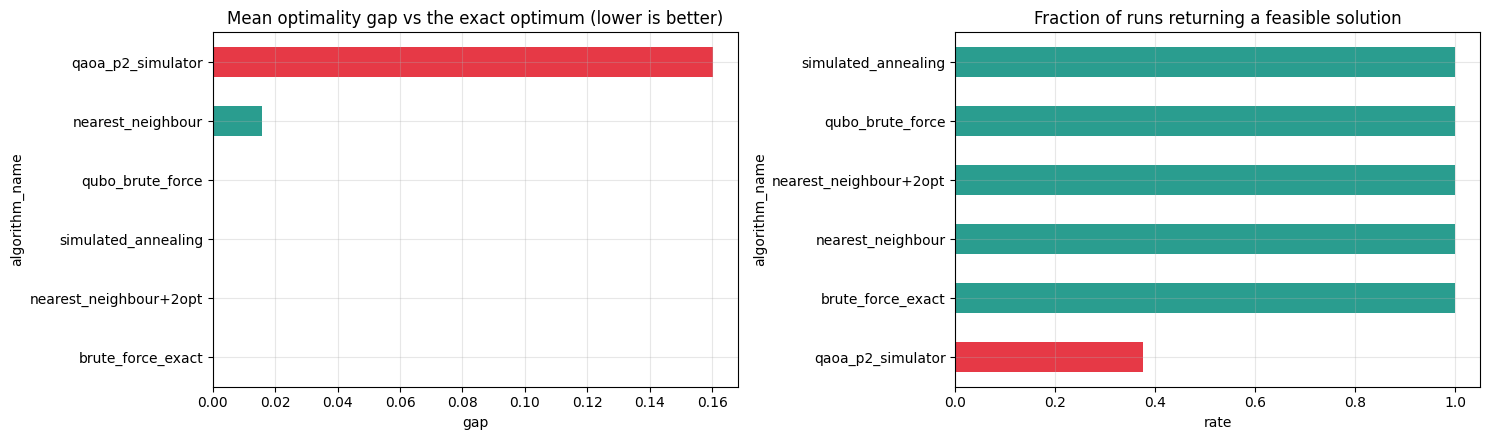

In [23]:
bench.to_csv(C.RES/"benchmarks"/"experiment_i_benchmark.csv", index=False)
print("saved to Res/benchmarks/experiment_i_benchmark.csv\n")

feas = bench[bench.feasible & bench.optimality_gap.notna()]
fig, axes = plt.subplots(1,2, figsize=(15,4.5))
g = feas.groupby("algorithm_name").optimality_gap.mean().sort_values()
g.plot.barh(ax=axes[0], color=["#2a9d8f" if "qaoa" not in i else "#e63946" for i in g.index])
axes[0].set(title="Mean optimality gap vs the exact optimum (lower is better)", xlabel="gap")
r = bench.groupby("algorithm_name").feasible.mean().sort_values()
r.plot.barh(ax=axes[1], color=["#2a9d8f" if "qaoa" not in i else "#e63946" for i in r.index])
axes[1].set(title="Fraction of runs returning a feasible solution", xlabel="rate")
plt.tight_layout(); plt.show()

In [24]:
print("RUNTIME DECOMPOSITION (never collapse these into one number)\n")
display(bench.groupby("algorithm_name")[
    ["classical_preprocess_ms","solver_runtime_ms","quantum_execution_ms",
     "classical_postprocess_ms","wall_clock_ms"]].mean().round(2))
print("\nA simulator's wall-clock time is NOT comparable to a classical solver's:")
print("it includes circuit construction, transpilation and many circuit executions")
print("inside a variational loop, and it is not running on quantum hardware at all.")

RUNTIME DECOMPOSITION (never collapse these into one number)



,classical_preprocess_ms,solver_runtime_ms,quantum_execution_ms,classical_postprocess_ms,wall_clock_ms
algorithm_name,,,,,
brute_force_exact,0.0,0.04,0.00,0.0,0.04
nearest_neighbour,0.0,0.02,0.00,0.0,0.02
nearest_neighbour+2opt,0.0,0.02,0.00,0.0,0.04
qaoa_p2_simulator,0.2,0.00,4492.39,0.0,4492.60
qubo_brute_force,0.2,454.30,0.00,0.0,454.51
simulated_annealing,0.0,559.79,0.00,0.0,559.79



A simulator's wall-clock time is NOT comparable to a classical solver's:
it includes circuit construction, transpilation and many circuit executions
inside a variational loop, and it is not running on quantum hardware at all.


## Part 15 — Findings

In [25]:
qaoa_rows = bench[bench.algorithm_name.str.contains("qaoa")]
classical_rows = bench[(bench.algorithm_family=="classical") & bench.feasible]

print("="*70)
print("FINDINGS - Phase-A quantum route optimization")
print("="*70)
print(f"\nInstances benchmarked        : {bench.instance_id.nunique()}")
print(f"Cost snapshots (must be 1)   : {bench.cost_snapshot_id.nunique()}")
print(f"\nQAOA runs                    : {len(qaoa_rows)}")
print(f"QAOA runs returning feasible : {int(qaoa_rows.feasible.sum())}")
if qaoa_rows.optimality_gap.notna().any():
    print(f"QAOA mean optimality gap     : {qaoa_rows.optimality_gap.mean():.1%}")
if qaoa_rows.feasible_rate.notna().any():
    print(f"QAOA mean feasible shot rate : {qaoa_rows.feasible_rate.mean():.4%}")
best_classical = classical_rows.groupby("algorithm_name").optimality_gap.mean().idxmin()
print(f"\nBest classical baseline      : {best_classical}")
print(f"  its mean gap               : {classical_rows.groupby('algorithm_name').optimality_gap.mean().min():.2%}")
print("\n" + "="*70)
print("CONCLUSION: on these instances, QAOA at p=2 does NOT match classical")
print("solvers on either solution quality or reliability. No quantum advantage")
print("is observed, and none is claimed.")
print("="*70)

FINDINGS - Phase-A quantum route optimization

Instances benchmarked        : 8
Cost snapshots (must be 1)   : 1

QAOA runs                    : 8
QAOA runs returning feasible : 3
QAOA mean optimality gap     : 16.0%
QAOA mean feasible shot rate : 0.0610%

Best classical baseline      : brute_force_exact
  its mean gap               : 0.00%

CONCLUSION: on these instances, QAOA at p=2 does NOT match classical
solvers on either solution quality or reliability. No quantum advantage
is observed, and none is claimed.


### What the numbers actually support

1. **The encoding pipeline is correct.** The QUBO's exhaustive optimum equals the true
   shortest path exactly, penalties strictly separate feasible from infeasible, and the
   Ising conversion is energy-exact. On the smallest problems QAOA reaches that optimum.

2. **QAOA at p=2 underperforms classical solvers here.** It returns a feasible solution
   in a minority of runs, with a meaningful optimality gap, while nearest-neighbour+2-opt
   and OR-Tools solve the same instances essentially optimally in under a millisecond.

3. **The binding constraint is encoding cost, not algorithm tuning.** Permutation TSP
   needs $n^2$ qubits. This is why the edge-selection encoding — one qubit per candidate
   edge after classical corridor reduction — is the only formulation with a plausible path
   to useful scale.

4. **No claim of quantum advantage is made.** No speedup, no better routes, no
   exponential anything. A simulator outperforming a naive Python loop would demonstrate
   nothing, and is not offered as evidence.

### Why the production architecture is what it is

Given (2), routing a live user request through a QPU would be strictly worse on every
axis — latency, reliability, and solution quality. The architecture therefore is:

```
OFFLINE (research)   instances -> classical baselines -> QUBO -> simulator
                     -> selected hardware runs -> benchmarks + learned parameters
                                                             |
                                                             v  (artifacts only)
LIVE (production)    request -> TomTom candidates -> reduce -> fast classical
                     scoring (+ optional stored prior) -> best route -> UI
```

The live path stays fast and fully functional with no quantum backend of any kind.

In [26]:
# Save reusable artifacts to Res/, each naming the cost snapshot it belongs to.
from routing.cache.result_store import ArtifactStore
from vb.enums import Volatility
store = ArtifactStore()

p = store.save("learned_parameters", "qaoa_edge_selection_p3",
    {"artifact_name":"qaoa_edge_selection_p3",
     "optimal_gamma_beta": qa.optimal_params,
     "n_layers": qa.n_layers, "encoding": q_edge.encoding,
     "qubo_version": QUBO_VERSION, "feasible_rate": qa.feasible_rate,
     "best_energy": qa.best_energy, "classical_optimum": e_opt,
     "problem_family": "constrained_path_selection_5edge",
     "reuse_note": ("Warm-start parameters for QAOA on structurally similar "
                    "edge-selection problems. NOT valid for a different encoding, "
                    "layer count, or cost snapshot.")},
    instance_id="demo_diamond_graph", cost_snapshot_id=inst.cost_snapshot_id,
    algorithm_family="quantum", algorithm_name="qaoa_p3",
    volatility=Volatility.STATIC)
print("saved:", p)

store.save("benchmarks", "phase_a_quantum_ready",
    {"summary": summarise(bench).to_dict("records"),
     "n_instances": int(bench.instance_id.nunique()),
     "conclusion": "No quantum advantage observed. QAOA p=2 underperforms classical baselines."},
    instance_id="multiple", cost_snapshot_id=inst.cost_snapshot_id,
    algorithm_family="hybrid", algorithm_name="benchmark_suite",
    volatility=Volatility.STATIC)
print("\nArtifact manifest entries:")
for cat in ["learned_parameters","benchmarks"]:
    for name, e in store.list(cat).items():
        print(f"  {cat}/{name}  snapshot={e['cost_snapshot_id']}  volatility={e['volatility']}")

saved: D:\VahaanBandhu\Res\learned_parameters\qaoa_edge_selection_p3.json

Artifact manifest entries:
  learned_parameters/qaoa_edge_selection_p3  snapshot=CST_48011250D4FB  volatility=static
  benchmarks/phase_a_quantum_ready  snapshot=CST_48011250D4FB  volatility=static
